# 时间序列分析模型

## MA移动平均模型

### 贵州茅台股票价格趋势

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 读取股票数据
data = pd.read_csv(r'C:/Users/86157/Desktop/茅台2023年股价.csv', parse_dates=True, index_col=0)
data.columns = ['Open', 'High', 'Low', 'Close','Volume','Amount'] 
data.index.name='Date'
#计算收盘价的滚动平均值和滚动标准差
rolling_mean = data['Close'].rolling(window=30,min_periods=1).mean()
rolling_std = data['Close'].rolling(window=30,min_periods=1).std()
#绘制收盘的折线图和滚动平均值和滚动标准差的线图
plt.figure(figsize=(10,6))
plt.plot(data['Close'],label='Close')
plt.plot(rolling_mean,label='滚动平均值',color='red')
plt.fill_between(rolling_std.index,rolling_mean-2 * rolling_std,rolling_mean
                + 2 * rolling_std,color='pink',alpha=0.5,label='滚动标准差')
plt.xlabel('日期')
plt.ylabel('价格')
plt.title('贵州茅台股票收盘价及滚动统计图')
plt.legend()
plt.show()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\86157\.conda\envs\ml-env\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\86157\.conda\envs\ml-env\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\86157\.conda\envs\ml-env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\86157\.conda\envs\ml-env\lib\site-packages\traitlets\config\application.py", line 1043, in launch_instance
    app.start()
  File "C

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

### 进行MA模型分析

In [1]:
#设置滞后阶数q,并且使用移动平均模型进行分析
q=3
model = sm.tsa.ARIMA(data['Close'],order=(0,0,q))
results = model.fit()
#打印结果
print(results.summary())
#模型系数(coefficient)
#标准差(standard error)
#t值(t-value)
#显著性水平(p-value)
#置信区间(confidence interval)

NameError: name 'sm' is not defined

### 预测未来的价格

In [63]:
# 定义预测范围的日期
start_date = '2023-03-11'
end_date = '2023-12-21'

# 使用日期索引来指定预测的起始和结束，需确保 data 的索引是日期类型且格式匹配
# 先找到数据中最后一个日期的位置，作为预测的起始点
start_idx = len(data)
# 预测的结束位置通过日期范围的长度来确定
end_idx = start_idx + (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days

# 使用模型进行价格预测
forecast_values = results.predict(start=start_idx, end=end_idx)

# 为预测结果添加日期索引，方便查看
forecast_series = pd.Series(forecast_values.values, index=pd.date_range(start=start_date, end=end_date))

print('预测2023年8月之后的股票价格为:')
print(forecast_series)

预测2023年8月之后的股票价格为:
2023-03-11    1742.671996
2023-03-12    1747.472307
2023-03-13    1752.364185
2023-03-14    1767.816172
2023-03-15    1767.816172
                 ...     
2023-12-17    1767.816172
2023-12-18    1767.816172
2023-12-19    1767.816172
2023-12-20    1767.816172
2023-12-21    1767.816172
Freq: D, Length: 286, dtype: float64


C:\Users\86157\.conda\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 与实际的价格对比

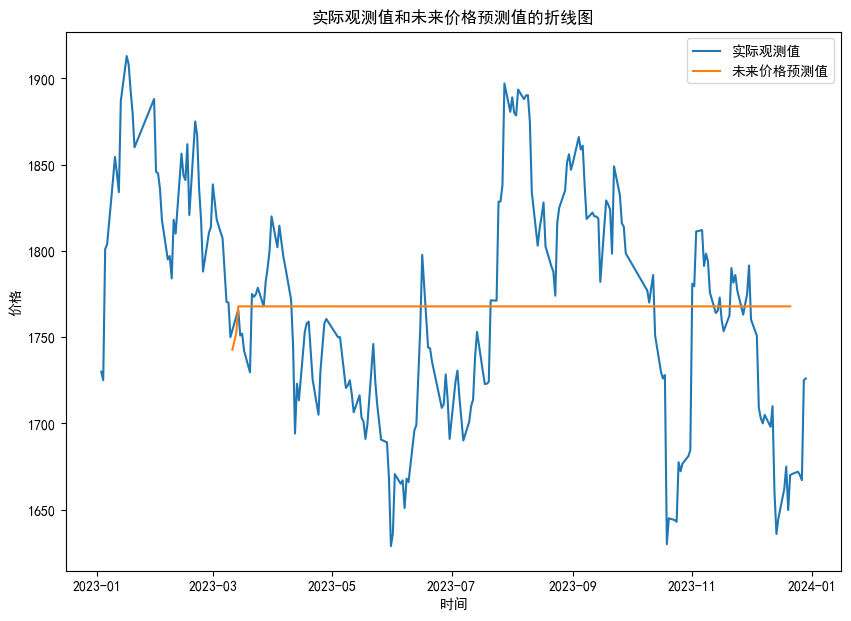

In [64]:
#实际值
actual_values = data["Close"]
#未来价格预测
future_predictions = forecast_values
plt.figure(figsize=(10,7))
#绘制实际观测值和未来价格预测的折线图
plt.plot(actual_values.index,actual_values.values,label='实际观测值')
# 创建未来预测值的日期索引
future_dates = pd.date_range(start=start_date, end=end_date)
# 绘制未来价格预测值，将预测值与日期索引对应
plt.plot(future_dates, future_predictions, label='未来价格预测值')
plt.xlabel('时间')
plt.ylabel('价格')
plt.title('实际观测值和未来价格预测值的折线图')
plt.legend()
plt.show()

## AR自回归模型

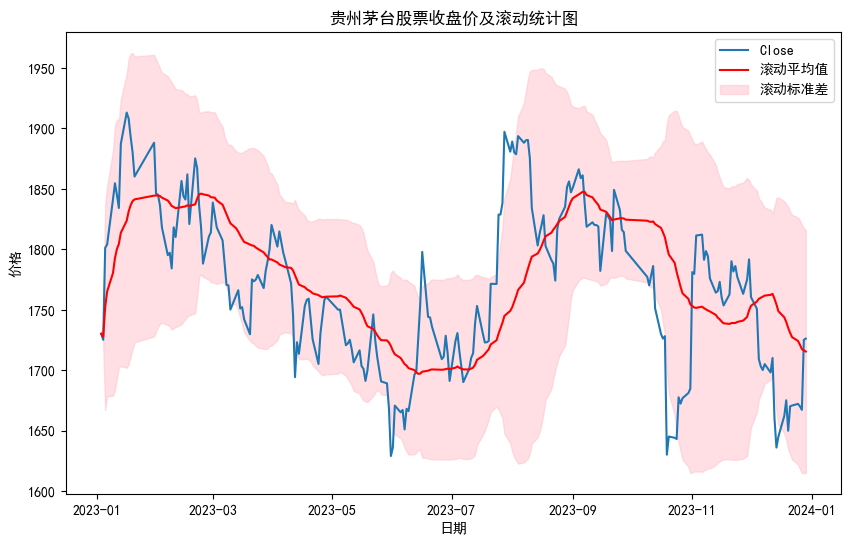

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 读取股票数据
data = pd.read_csv(r'C:/Users/86157/Desktop/茅台2023年股价.csv', parse_dates=True, index_col=0)
data.columns = ['Open', 'High', 'Low', 'Close','Volume','Amount'] 
data.index.name='Date'
#计算收盘价的滚动平均值和滚动标准差
rolling_mean = data['Close'].rolling(window=30,min_periods=1).mean()
rolling_std = data['Close'].rolling(window=30,min_periods=1).std()
#绘制收盘的折线图和滚动平均值和滚动标准差的线图
plt.figure(figsize=(10,6))
plt.plot(data['Close'],label='Close')
plt.plot(rolling_mean,label='滚动平均值',color='red')
plt.fill_between(rolling_std.index,rolling_mean-2 * rolling_std,rolling_mean
                + 2 * rolling_std,color='pink',alpha=0.5,label='滚动标准差')
plt.xlabel('日期')
plt.ylabel('价格')
plt.title('贵州茅台股票收盘价及滚动统计图')
plt.legend()
plt.show()

### 进行AR模型分析

In [66]:
#设置滞后的阶数并使用移动平均模型分析
p=3
model = sm.tsa.ARIMA(data['Close'],order=(p,0,0))
results = model.fit()
#打印结果
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  242
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1095.025
Date:                Sun, 07 Sep 2025   AIC                           2200.051
Time:                        21:48:54   BIC                           2217.495
Sample:                             0   HQIC                          2207.078
                                - 242                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1768.2816     21.786     81.167      0.000    1725.583    1810.981
ar.L1          0.9196      0.078     11.809      0.000       0.767       1.072
ar.L2          0.1406      0.115      1.227      0.2

C:\Users\86157\.conda\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [67]:
# 定义预测范围的日期
start_date = '2023-08-01'
end_date = '2023-12-31'

# 使用日期索引来指定预测的起始和结束，需确保 data 的索引是日期类型且格式匹配
# 先找到数据中最后一个日期的位置，作为预测的起始点
start_idx = len(data)
# 预测的结束位置通过日期范围的长度来确定
end_idx = start_idx + (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days

# 使用模型进行价格预测
forecast_values = results.predict(start=start_idx, end=end_idx)

# 为预测结果添加日期索引，方便查看
forecast_series = pd.Series(forecast_values.values, index=pd.date_range(start=start_date, end=end_date))

print('预测2023年8月之后的股票价格为:')
print(forecast_series)

预测2023年8月之后的股票价格为:
2023-08-01    1736.216340
2023-08-02    1738.368349
2023-08-03    1741.655037
2023-08-04    1743.677666
2023-08-05    1745.725452
                 ...     
2023-12-27    1768.281423
2023-12-28    1768.281438
2023-12-29    1768.281452
2023-12-30    1768.281465
2023-12-31    1768.281477
Freq: D, Length: 153, dtype: float64


C:\Users\86157\.conda\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


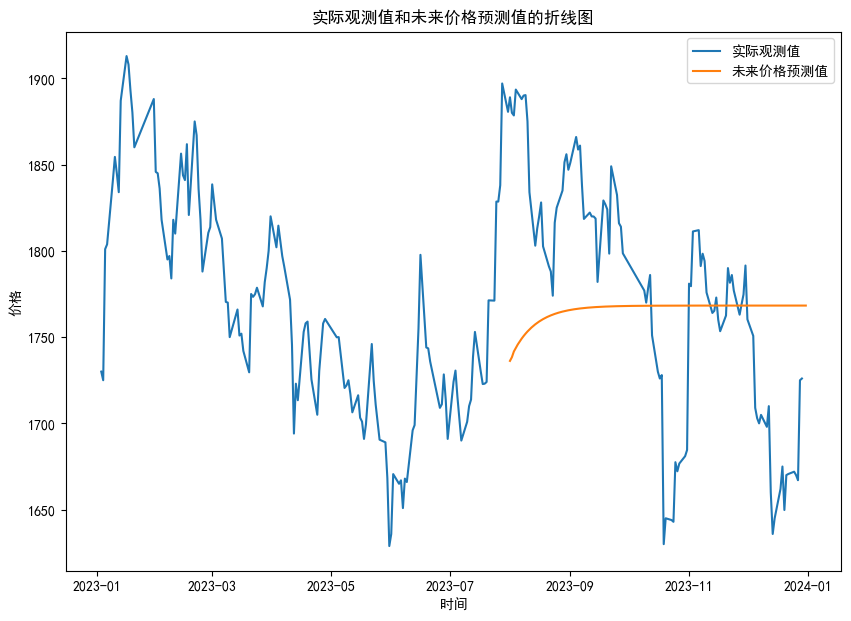

In [68]:
#实际值
actual_values = data["Close"]
#未来价格预测
future_predictions = forecast_values
plt.figure(figsize=(10,7))
#绘制实际观测值和未来价格预测的折线图
plt.plot(actual_values.index,actual_values.values,label='实际观测值')
# 创建未来预测值的日期索引
future_dates = pd.date_range(start=start_date, end=end_date)
# 绘制未来价格预测值，将预测值与日期索引对应
plt.plot(future_dates, future_predictions, label='未来价格预测值')
plt.xlabel('时间')
plt.ylabel('价格')
plt.title('实际观测值和未来价格预测值的折线图')
plt.legend()
plt.show()